# Design of Experiments and a First Data-Based Model
### MECH 559 - Systems Optimization - L04

This notebook builds and compares sampling plans (full factorial, random, Latin
hypercube) and then uses one of them to fit a first polynomial surrogate model,
evaluated with RMSE and $R^2$ on held-out data.

## Learning objectives

By the end, you should be able to:

1. Generate full-factorial, random, and Latin hypercube sampling plans.
2. Quantify how well a plan fills the design space (a maximin distance metric).
3. Fit a polynomial surrogate $\hat f(\mathbf x)$ by least squares and evaluate it
   with RMSE and $R^2$ on a held-out test set.
4. Observe how the training-set size $p$ and the polynomial degree interact to
   produce underfitting or overfitting.

> **Classroom rhythm:** I will pause at each **Predict** prompt before running the next cell.

In [2]:
import itertools

import numpy as np
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

rng = np.random.default_rng(559)
plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
COLORS = {"grid": "#264653", "random": "#D1495B", "lhs": "#2A9D8F", "fit": "#00798C", "test": "#EDAE49"}
print(f"Optional widgets available: {WIDGETS_AVAILABLE}")

Optional widgets available: True


---
## 1. Three sampling plans

Given a budget of $p$ points over $\mathcal X = [0,1]^n$, we compare:

- **Full factorial (grid):** all combinations of $k$ levels per variable ($p=k^n$).
- **Pure random:** $p$ points drawn uniformly at random.
- **Latin hypercube (LHS):** each of the $p$ points occupies its own stratum
  (equal-width interval) along *every* variable, so 1-D projections are always
  well spread. We build it exactly as in the lecture: stratify each axis into
  $p$ intervals, draw one random value per interval, then independently permute
  the interval order for each variable.

> **Predict:** which plan will have the *largest* minimum distance between any
> two points (the "maximin" criterion) for the same budget $p$?

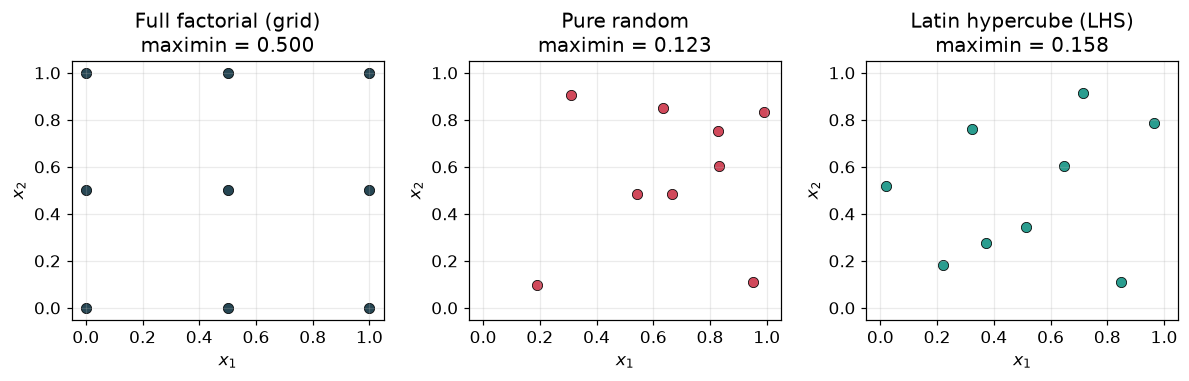

All three plans use the same budget p = 9


In [3]:
def full_factorial(k, n_dims=2):
    levels = np.linspace(0, 1, k)
    grids = np.meshgrid(*([levels] * n_dims), indexing="ij")
    return np.column_stack([g.ravel() for g in grids])


def random_sample(p, n_dims=2, generator=rng):
    return generator.uniform(0.0, 1.0, size=(p, n_dims))


def latin_hypercube(p, n_dims=2, generator=rng):
    # Stratify each axis into p equal intervals, one sample per interval, then
    # permute the interval order independently for every dimension.
    edges = np.linspace(0, 1, p + 1)
    points = np.empty((p, n_dims))
    for dim in range(n_dims):
        interval_low = edges[:-1]
        offsets = generator.uniform(0.0, 1.0, size=p) * (1.0 / p)
        values = interval_low + offsets
        points[:, dim] = generator.permutation(values)
    return points


def maximin_distance(points):
    # Smallest pairwise Euclidean distance -- larger is more space-filling.
    diffs = points[:, None, :] - points[None, :, :]
    dist = np.sqrt((diffs**2).sum(-1))
    np.fill_diagonal(dist, np.inf)
    return dist.min()


p = 9  # p = 3^2, so the grid uses k=3 levels per axis
plans = {
    "Full factorial (grid)": full_factorial(k=3, n_dims=2),
    "Pure random": random_sample(p),
    "Latin hypercube (LHS)": latin_hypercube(p),
}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, (name, X), color in zip(axes, plans.items(), [COLORS["grid"], COLORS["random"], COLORS["lhs"]]):
    ax.scatter(X[:, 0], X[:, 1], s=45, color=color, edgecolor="black", linewidth=0.5)
    ax.set(xlim=(-0.05, 1.05), ylim=(-0.05, 1.05), xlabel="$x_1$", ylabel="$x_2$",
           title=f"{name}\nmaximin = {maximin_distance(X):.3f}")
plt.tight_layout(); plt.show()

for name, X in plans.items():
    assert X.shape == (p, 2)
print("All three plans use the same budget p =", p)

The grid needs $k^n$ points, so it does not even give us a *choice* of budget
$p$ in general -- and it explodes combinatorially with dimension $n$ (the
**curse of dimensionality**). Pure random sampling can leave gaps or cluster
points by chance. LHS usually gives the best maximin distance for a fixed $p$
because it forbids two points from ever sharing a stratum along any axis.

> **Predict:** if you increase $p$ from 9 to 100, will pure random sampling's
> maximin distance ever catch up to LHS's? Try it below.

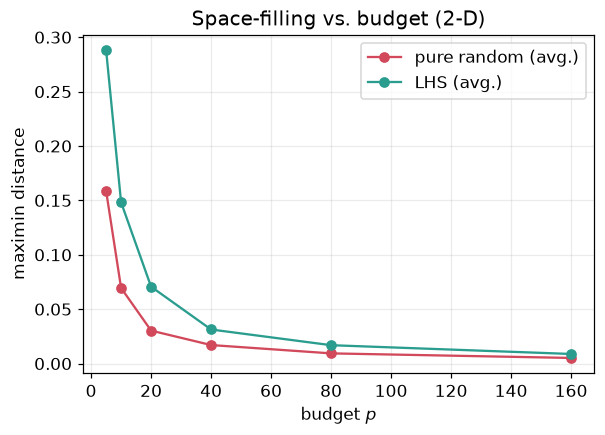

LHS has the larger maximin distance in 6 out of 6 budgets tested.


In [4]:
def compare_budgets(p_values, n_dims=2, n_repeats=20, generator=rng):
    random_scores = []
    lhs_scores = []
    for p_value in p_values:
        random_scores.append(np.mean([maximin_distance(random_sample(p_value, n_dims, generator))
                                       for _ in range(n_repeats)]))
        lhs_scores.append(np.mean([maximin_distance(latin_hypercube(p_value, n_dims, generator))
                                    for _ in range(n_repeats)]))
    return np.array(random_scores), np.array(lhs_scores)


p_values = np.array([5, 10, 20, 40, 80, 160])
random_scores, lhs_scores = compare_budgets(p_values)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p_values, random_scores, "o-", color=COLORS["random"], label="pure random (avg.)")
ax.plot(p_values, lhs_scores, "o-", color=COLORS["lhs"], label="LHS (avg.)")
ax.set(xlabel="budget $p$", ylabel="maximin distance", title="Space-filling vs. budget (2-D)")
ax.legend(); plt.show()

assert (lhs_scores >= random_scores).mean() > 0.8, "LHS should usually win the maximin comparison"
print("LHS has the larger maximin distance in", int((lhs_scores >= random_scores).sum()),
      "out of", len(p_values), "budgets tested.")

---
## 2. Fit a first polynomial surrogate

We now sample a moderately complex 2-D function with an LHS plan, fit a
polynomial model $\hat f(\mathbf x)$ by least squares, and evaluate it on a
**separate** held-out test set (never used for fitting).

$$f(x_1,x_2) = (x_1-0.3)^2 + 3(x_2-0.6)^2 + 0.5\sin(6x_1)\cos(4x_2)$$

In [5]:
def true_function(X):
    x1, x2 = X[:, 0], X[:, 1]
    return (x1 - 0.3) ** 2 + 3 * (x2 - 0.6) ** 2 + 0.5 * np.sin(6 * x1) * np.cos(4 * x2)


def polynomial_features(X, degree):
    # All monomials x1^a * x2^b with a + b <= degree.
    n_dims = X.shape[1]
    columns = []
    for total_degree in range(degree + 1):
        for powers in itertools.product(range(total_degree + 1), repeat=n_dims):
            if sum(powers) == total_degree:
                columns.append(np.prod([X[:, d] ** powers[d] for d in range(n_dims)], axis=0))
    return np.column_stack(columns)


def fit_and_score(X_train, y_train, X_test, y_test, degree):
    Z_train = polynomial_features(X_train, degree)
    w, *_ = np.linalg.lstsq(Z_train, y_train, rcond=None)
    y_train_hat = Z_train @ w
    y_test_hat = polynomial_features(X_test, degree) @ w

    def rmse(y, y_hat):
        return np.sqrt(np.mean((y - y_hat) ** 2))

    def r_squared(y, y_hat):
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1 - ss_res / ss_tot

    return {
        "w": w,
        "train_rmse": rmse(y_train, y_train_hat),
        "test_rmse": rmse(y_test, y_test_hat),
        "train_r2": r_squared(y_train, y_train_hat),
        "test_r2": r_squared(y_test, y_test_hat),
    }


X_train = latin_hypercube(p=25, n_dims=2, generator=rng)
y_train = true_function(X_train)
X_test = random_sample(p=200, n_dims=2, generator=rng)
y_test = true_function(X_test)

result = fit_and_score(X_train, y_train, X_test, y_test, degree=4)
print(f"degree=4: train RMSE={result['train_rmse']:.4f}, test RMSE={result['test_rmse']:.4f}, "
      f"train R2={result['train_r2']:.4f}, test R2={result['test_r2']:.4f}")
assert result["test_r2"] > 0.8, "a degree-4 fit with 25 LHS points should already explain most of the variance"

degree=4: train RMSE=0.0353, test RMSE=0.0624, train R2=0.9923, test R2=0.9778


---
## 3. Underfitting and overfitting vs. degree and budget

> **Predict:** as the polynomial degree grows for a *fixed* training budget,
> what should happen to the training RMSE? What should eventually happen to the
> test RMSE?

In [6]:
def degree_sweep(p_train, degrees, n_test=200, generator=rng):
    X_train = latin_hypercube(p_train, 2, generator)
    y_train = true_function(X_train)
    X_test = random_sample(n_test, 2, generator)
    y_test = true_function(X_test)

    train_rmses, test_rmses = [], []
    for degree in degrees:
        result = fit_and_score(X_train, y_train, X_test, y_test, degree)
        train_rmses.append(result["train_rmse"])
        test_rmses.append(result["test_rmse"])
    return np.array(train_rmses), np.array(test_rmses)


def plot_degree_sweep(p_train=12, max_degree=9):
    degrees = np.arange(1, max_degree + 1)
    train_rmses, test_rmses = degree_sweep(p_train, degrees)

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.semilogy(degrees, train_rmses, "o-", color=COLORS["fit"], label="training RMSE")
    ax.semilogy(degrees, test_rmses, "o-", color=COLORS["test"], label="test RMSE")
    ax.set(xlabel="polynomial degree", ylabel="RMSE (log scale)",
           title=f"Under/overfitting vs. degree (p={p_train} training points)")
    ax.legend(); plt.show()
    best_degree = degrees[np.argmin(test_rmses)]
    print(f"Best test RMSE at degree={best_degree} (test RMSE={test_rmses.argmin() and test_rmses.min():.4f})")


if WIDGETS_AVAILABLE:
    display(widgets.interactive(
        plot_degree_sweep,
        p_train=widgets.IntSlider(value=12, min=6, max=60, step=2, description="p (train)"),
        max_degree=widgets.IntSlider(value=9, min=3, max=12, step=1, description="max degree"),
    ))
else:
    plot_degree_sweep()

interactive(children=(IntSlider(value=12, description='p (train)', max=60, min=6, step=2), IntSlider(value=9, …

With few training points, the test RMSE eventually turns back *up* as the
degree grows even though the training RMSE keeps falling -- the classic
underfitting/overfitting picture from the lecture, now with numbers attached.
Adding more training points (drag the `p (train)` slider up) delays the point
at which the test error turns up, because there is more data to constrain the
extra coefficients.

## Takeaways

1. LHS gives markedly better space-filling than pure random sampling for the
   same budget, and it needs far fewer points than a full-factorial grid.
2. A held-out test set (never used for fitting) is what actually reveals
   over/underfitting -- training error alone is misleading.
3. For a fixed budget, there is a "sweet spot" polynomial degree; past it,
   test error increases even though training error keeps decreasing.

## Classroom exercises

1. Increase `p (train)` until the degree-9 fit no longer overfits. Roughly how
   many points were needed?
2. Change `true_function` to remove the `sin`/`cos` term (a pure quadratic) and
   re-run the degree sweep. Does the sweet-spot degree change? Why?
3. Modify `latin_hypercube` to *not* permute the strata (just take the interval
   midpoints) and compare its maximin distance to the permuted version.